### 0. Preliminaries
Import necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

### 1. Model Setup
Define constant parameters, user functions, and simulation individuals

In [2]:
# Define constant parameters
county_size = 20 # miles
taxi_speed = 20 # miles per hour
base_fare = 3.00 # pounds
per_mile_fare = 2.00 # pounds per mile
petrol_cost = 0.2 # pounds per mile

In [3]:
def distance(loc1, loc2):
    return np.sqrt((loc1[0] - loc2[0])**2 + (loc1[1] - loc2[1])**2)

def generate_location():
    return (random.uniform(0, county_size), random.uniform(0, county_size))

def travel_time(d_OD):
    mu = d_OD / taxi_speed
    return random.uniform(0.8*mu, 1.2*mu) 

### 2. Simulation

In [4]:
TNOW = 0
# insert performance metrics here (alice)
Termination = 100 #hrs
EventTypes = ['DriverArrival', 'RiderArrival', 'PickupStart', 
              'Pickup', 'Dropoff', 'RiderAbandonment', 'DriverOffline', 'Termination']
EventCalendar = []

def schedule_event(time, event_type, data=None):
    '''Event scheduler that keeps track of times, event type, and user data (optional)'''
    EventCalendar.append((time,event_type,data))

drivers =[]
idle_drivers=[]
riders = []
waiting_riders=[]

driver_id_counter = 0
rider_id_counter = 0

completed_rides = 0
abandoned_rides = 0

schedule_event(random.expovariate(3), 1)   # 1 = Driver Arrival
schedule_event(random.expovariate(30), 2)    # 2 = Rider Arrival
schedule_event(Termination, 8)                      # 8 = Termination

In [5]:
while TNOW < Termination:
    TNEXT, TypeNext, Data = min(EventCalendar, key=lambda x: x[0])
    EventCalendar.remove((TNEXT, TypeNext, Data))

    ## Update Performance Stats Here (Alice)

    TNOW = TNEXT

    # DriverArrival
    if TypeNext == 1:
        driver_id_counter += 1

        # Generate driver location and offline time (initialize other attributes)
        driver = {
            "id": driver_id_counter,
            "location": generate_location(),
            'offline_time': TNOW + random.uniform(5,8),
            'idle': True,
            'active': True,
            'earnings': 0
        }
        drivers.append(driver)
        
        # Schedule offline time
        schedule_event(driver['offline_time'], event_type=7, data=driver)

        # Match driver to waiting rider
        if waiting_riders:
            # match closest waiting rider
            rider = min(waiting_riders, key = lambda r:distance(driver['location'], r['origin']))
            waiting_riders.remove(rider)
            
            # update statuses
            rider['status'] = 'matched'
            driver['idle'] = False
            
            # schedule pickup start
            schedule_event(TNOW, event_type=3, data=(driver, rider)) 
        else:
            idle_drivers.append(driver)
        
        # Schedule next driver arrival
        schedule_event(TNOW + random.expovariate(3), event_type=1)

    # RiderArrival
    elif TypeNext == 2: 
        rider_id_counter += 1

        # Generate rider location and patience time (initialize other attributes)
        rider = {
            "id": rider_id_counter,
            "origin": generate_location(),
            'destination': generate_location(),
            'patience_deadline': TNOW + random.expovariate(5),
            'status': 'waiting',
        }
        
        # Match driver to idle driver
        if idle_drivers:
            # match to closest driver
            driver = min(idle_drivers, key = lambda d:distance(d['location'], rider['origin']))
            idle_drivers.remove(driver)

            # update statuses
            rider['status'] = 'matched'
            driver['idle'] = False

            # schedule PickupStart
            schedule_event(TNOW, event_type=3, data=(driver,rider))
        else:
            waiting_riders.append(rider)

            #schedule patience deadline for waiting rider
            schedule_event(rider['patience_deadline'], event_type=6, data=rider)
        
        # schedule next rider arrival
        schedule_event(TNOW + random.expovariate(30), event_type=2)

    # PickupStart
    elif TypeNext == 3:
        driver,rider = Data

        if not driver['active']:
            continue
        
        # Calculate actual travel time 
        d1 = distance(driver['location'],rider['origin'])
        t1 = travel_time(d1)

        # Schedule Pickup event
        schedule_event(TNOW + t1, event_type=4, data=(driver,rider,d1))
    
    # Pickup
    elif TypeNext == 4:
        driver, rider, d1 = Data
        
        # Calculate actual travel time
        d2 = distance(rider['origin'], rider['destination'])
        t2 = travel_time(d2)

        # Schedule Dropoff
        schedule_event(TNOW + t2, event_type=5, data=(driver,rider,d1,d2))

    # Dropoff
    elif TypeNext == 5:
        driver, rider, d1, d2 = Data

        # complete the ride and update rider status
        completed_rides += 1
        rider["status"] = "dropped-off"

        # calculate driver earnings
        rider_fare = base_fare + per_mile_fare * d2
        driver_cost = petrol_cost*(d1+d2)
        driver['earnings'] =  rider_fare - petrol_cost
        
        # Update driver information
        driver['location'] = rider['destination']
        driver['idle'] = True

        # Check if driver is meant to be offline now
        if TNOW >= driver['offline_time']:
            driver['active'] = False
        else:
            if waiting_riders:
                next_rider = min(waiting_riders,
                                 key=lambda r: distance(driver['location'], r['origin']))
                waiting_riders.remove(next_rider)
                next_rider['status'] = 'matched'
                driver['idle'] = False
                # schedule next pickup if driver gets matched to a new rider
                schedule_event(TNOW, event_type=3, data=(driver, next_rider))
            else:
                idle_drivers.append(driver)
    
    # RiderAbandonment
    elif TypeNext == 6:
        rider = Data

        # remove abandonded riders and update status
        if rider['status'] == 'waiting':
            waiting_riders.remove(rider)
            rider["status"] = "abandoned"
            abandoned_rides += 1
    
    # DriverOffline
    elif TypeNext == 7:
        driver = Data
        
        # remove offline drivers and update status
        if driver["active"] and driver["idle"]:
            driver["active"] = False
            if driver in idle_drivers:
                idle_drivers.remove(driver)

    else:
        ## final performance metric stats calc here (alice)
        break




### 2. Analyze Simulation Results

### 3. Manually Simulate with Given Data

The `riders.xlsx` and `drivers.xlsx` data sets are provided from the project assignment page. 

In [6]:
riders_df = pd.read_excel('riders.xlsx')
drivers_df = pd.read_excel('drivers.xlsx')

# Display head of the dataframes
display(drivers_df.head())
display(riders_df.head())

,id,arrival_time,offline_time,initial_location,current_location,status,arrival_datetime,offline_datetime
0,1,5.011975,11.638223,"(0.7897740952818868, 8.194226996886005)","(13.492895938215721, 17.375090044074234)",offline,2025-12-01 13:00:43.110,2025-12-01 19:38:17.601
1,2,5.557763,11.732854,"(4.600342938200451, 13.82151625336585)","(13.6809497478333, 15.070060581064372)",offline-scheduled,2025-12-01 13:33:27.947,2025-12-01 19:43:58.273
2,3,5.661047,12.723458,"(9.09829206926925, 11.669336718393772)","(15.86922281798255, 9.936190354974855)",offline-scheduled,2025-12-01 13:39:39.768,2025-12-01 20:43:24.450
3,4,5.757413,12.793147,"(14.723720219958555, 14.743429470057318)","(14.232702333916698, 12.939560071816741)",offline-scheduled,2025-12-01 13:45:26.686,2025-12-01 20:47:35.330
4,5,5.769205,12.431118,"(13.023825947458846, 12.501871643860605)","(19.845683334071563, 7.3885004325174215)",offline-scheduled,2025-12-01 13:46:09.139,2025-12-01 20:25:52.025


,id,request_time,pickup_time,dropoff_time,pickup_location,dropoff_location,status,request_datetime,pickup_datetime,dropoff_datetime
0,1,5.048803,5.372603,5.668817,"(8.52776815255513, 11.374422951736026)","(11.22406718305943, 18.28586415472845)",dropped-off,2025-12-01 13:02:55.690,2025-12-01 13:22:21.370,2025-12-01 13:40:07.743
1,2,5.113495,5.344117,5.658663,"(4.7260253234018075, 13.921168220313202)","(11.219433016467919, 9.224932723238288)",dropped-off,2025-12-01 13:06:48.580,2025-12-01 13:20:38.822,2025-12-01 13:39:31.187
2,3,5.114319,5.819045,6.154474,"(9.34931432850313, 14.855954034601385)","(15.818906976292498, 14.556629597532137)",dropped-off,2025-12-01 13:06:51.547,2025-12-01 13:49:08.563,2025-12-01 14:09:16.107
3,4,5.210384,5.492225,5.915581,"(5.341657715440439, 9.121586876730834)","(11.832789025965816, 11.90864135355879)",dropped-off,2025-12-01 13:12:37.383,2025-12-01 13:29:32.010,2025-12-01 13:54:56.092
4,5,5.229512,5.421566,6.019653,"(5.444067188695589, 13.774420071355813)","(11.208517457838962, 5.792638826367501)",dropped-off,2025-12-01 13:13:46.244,2025-12-01 13:25:17.639,2025-12-01 14:01:10.751


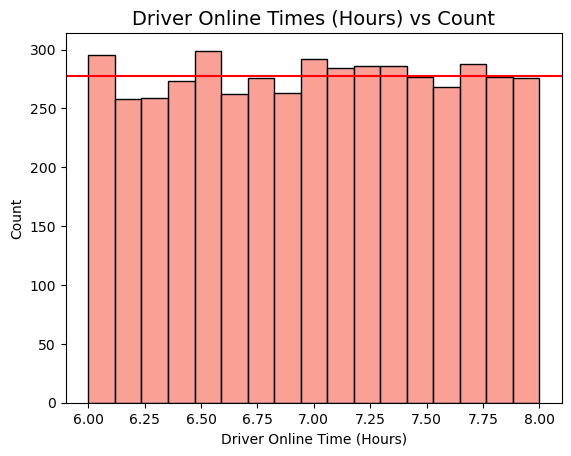

In [7]:
import seaborn as sns

# Extract driver arrival/offline times
driver_arrivals = drivers_df['arrival_time']
driver_offline = drivers_df['offline_time']

# Find and plot total driver work times
driver_work_times = driver_offline - driver_arrivals

sns.histplot(driver_work_times, color="salmon")
plt.title("Driver Online Times (Hours) vs Count", fontsize=14)
plt.xlabel("Driver Online Time (Hours)")

# Add horizontal line for expected number of counts in each bin
plt.axhline(y=len(driver_arrivals)/17, color="red")

In [ ]:
from scipy.stats import chi2

def chi2_unif_test(data, lower, upper, bins):
    '''
    This function takes a vector, data, and computes the observed Chi-squared test statistic
    for the null hypothesis that these data are independtly distributed Uniform(lower, upper)
    random variables. 

    Inputs:
        data (vector) - A vector of observed data to calculate the test statistic on
        lower (real)  - A real number representing the lower bound for the uniform distribution
        upper (real)  - A real number representing the upper bound for the uniform distribution
        bins (int)    - The number of bins to split these data into

    Output:
        The observed Chi-squared test statistic that these data are independently distributed
        Uniform(lower, upper) random variables.
    '''

    # Number of observations in data
    n = len(data)

    # Define breakpoints used
    breakpoints = np.linspace(lower, upper, bins+1)

    # Expected number of observations in each bin
    expec_per_bin = np.repeat(n/bins, bins)

    # Number of observations in each bin
    obs_per_bin = []

    for i in range(bins):
        obs_per_bin.append(sum((breakpoints[i] < driver_work_times) & (driver_work_times <= breakpoints[i+1])))

    # Return observed test statistic
    return(sum((obs_per_bin - expec_per_bin)**2/expec_per_bin))

# Define parameter values for chi-squared test
bins = 17
lower = 6
upper = 8

# Calculate the observed chi-squared statistic
chi2_obs = chi2_unif_test(data=driver_work_times, lower=lower, upper=upper, bins=bins)

# Print results:
print("The observed test statistic is", round(chi2_obs, 2),"and the critical value for these parameter values and data are:", round(chi2.ppf(1-0.05, df=bins-1), 2))

The observed test statistic is 8.98 and the critical value for these parameter values and data are: 26.3


We conclude fail to reject the null hypothesis that these data are not Uniform(6,8) random variables.